# Depth vs execution time (search complexity scaling)

## Goal

Measure how the execution time of the engine's two search variants —
`search.search_min_max` / `search.search_alpha_beta` (connect6/search.py) — scales with the
search depth, the key complexity parameter exposed by the engine's `depth d` command
(default 3). The two share one loop and differ only in a `prune` flag that turns alpha-beta's
window bounds on or off, so this notebook doubles as a correctness check: both variants must
return the same score at every shared depth.

## Expected behaviour

The naive variant explores `MAX_CANDIDATE_MOVES = 30` candidates at every node and performs
no pruning, so its tree for depth `d` contains

```
N(d) = 30^0 + 30^1 + ... + 30^d = (30^(d+1) - 1) / 29     nodes
```

and its time should follow `T(d) ≈ c · N(d)`, multiplying by ≈ 30 for every extra depth —
exponential `O(B^depth)` complexity.

Alpha-beta provably returns the same root score while skipping subtrees that cannot change
the decision. Its node count depends on move ordering — the candidate pipeline already puts
completion pairs (the forcing moves) first — and the theoretical bound is `O(B^(d/2))`:
with good ordering the effective branching factor drops from `B = 30` toward `√B ≈ 5.5`.

## Benchmark

The position is a fixed mid-game board — ten alternating stones clustered around the centre.
A mid-game board matters because both per-node costs are position-dependent: the evaluation
sweeps all cells and candidate generation scores every cell adjacent to a stone.

Each (variant, depth) pair is measured **once**, with a fresh node counter; both search a
board copy taken internally, so the benchmark board is reusable as-is. At these scales the
run-to-run noise is negligible next to the ×30 growth per depth, so averaging or best-of-N
sampling would add nothing. Naive depth 4 (~1 minute) is its last measurable point; the
pruned variant gets one more, depth 5 (~10 s), which naive could only reach in ~30 minutes.

In [1]:
import time

from connect6.board import init_board
from connect6.defines import GRID_NUM, MAX_CANDIDATE_MOVES, Color, Move, Position, SearchStats
from connect6.search import search_alpha_beta, search_min_max

DEPTHS = [1, 2, 3, 4]
PRUNED_DEPTHS = [1, 2, 3, 4, 5]
BRANCHING = MAX_CANDIDATE_MOVES


def create_benchmark_board():
    board = [[0] * GRID_NUM for _ in range(GRID_NUM)]
    init_board(board)
    stones = [
        (10, 10), (11, 10), (9, 11), (11, 9), (8, 12),
        (12, 8), (9, 9), (12, 11), (10, 12), (13, 9),
    ]
    for i, (x, y) in enumerate(stones):
        board[x][y] = Color.BLACK if i % 2 == 0 else Color.WHITE
    return board


def make_last_move(x, y):
    return Move((Position(x, y), Position(x, y)))


def measure_depth(depth, search):
    stats = SearchStats()
    board = create_benchmark_board()
    start = time.perf_counter()
    result = search(board, Color.BLACK, depth, make_last_move(13, 9), stats)
    return (time.perf_counter() - start) * 1000, stats.node_count, result.score


naive_results = [measure_depth(depth, search_min_max) for depth in DEPTHS]
pruned_results = [measure_depth(depth, search_alpha_beta) for depth in PRUNED_DEPTHS]

for (_, _, naive_score), (_, _, pruned_score) in zip(naive_results, pruned_results):
    assert naive_score == pruned_score, "alpha-beta disagrees with min-max"
print("alpha-beta returns the same score as min-max at every shared depth\n")

naive_times = [ms for ms, _, _ in naive_results]
naive_nodes = [n for _, n, _ in naive_results]
pruned_times = [ms for ms, _, _ in pruned_results]
pruned_nodes = [n for _, n, _ in pruned_results]

header = [
    "depth", "min-max time (ms)", "min-max nodes", "growth",
    "alpha-beta time (ms)", "alpha-beta nodes", "growth", "node cut",
]
rows = []
for i, depth in enumerate(PRUNED_DEPTHS):
    pruned_ms, pruned_n, _ = pruned_results[i]
    pruned_growth = "-" if i == 0 else f"{pruned_ms / pruned_times[i - 1]:.1f}"
    pruned_cells = [f"{pruned_ms:.1f}", f"{pruned_n:,}", pruned_growth]
    if depth in DEPTHS:
        j = DEPTHS.index(depth)
        naive_ms, naive_n, _ = naive_results[j]
        naive_growth = "-" if j == 0 else f"{naive_ms / naive_times[j - 1]:.1f}"
        rows.append([
            str(depth), f"{naive_ms:.1f}", f"{naive_n:,}", naive_growth,
            *pruned_cells, f"x{naive_n / pruned_n:.0f}",
        ])
    else:
        model_nodes = sum(BRANCHING ** k for k in range(depth + 1))
        model_minutes = naive_times[-1] * BRANCHING / 60_000
        rows.append([
            str(depth), f"(model: ~{model_minutes:.0f} min)", f"~{model_nodes:,}", "~30",
            *pruned_cells, f"~x{model_nodes / pruned_n:.0f}",
        ])

widths = [max(len(header[c]), *(len(row[c]) for row in rows)) for c in range(len(header))]


def print_row(cells):
    print("| " + " | ".join(cell.ljust(w) for cell, w in zip(cells, widths)) + " |")


print_row(header)
print("|" + "|".join("-" * (w + 2) for w in widths) + "|")
for row in rows:
    print_row(row)

alpha-beta returns the same score as min-max at every shared depth

| depth | min-max time (ms) | min-max nodes | growth | alpha-beta time (ms) | alpha-beta nodes | growth | node cut |
|-------|-------------------|---------------|--------|----------------------|------------------|--------|----------|
| 1     | 2.1               | 31            | -      | 1.8                  | 31               | -      | x1       |
| 2     | 58.1              | 931           | 27.5   | 24.9                 | 305              | 13.9   | x3       |
| 3     | 1852.9            | 27,931        | 31.9   | 158.5                | 1,857            | 6.4    | x15      |
| 4     | 58678.4           | 829,891       | 31.7   | 2316.2               | 20,035           | 14.6   | x41      |
| 5     | (model: ~29 min)  | ~25,137,931   | ~30    | 8926.8               | 84,039           | 3.9    | ~x299    |


## Charts

The **theoretical curve** is derived from the measurements themselves: the per-node cost `c`
is estimated as `c = time(depth 1) / nodes(depth 1)` from the naive run, and the model is
then `T(d) = c · Σ B^k` for `k = 0..d` with `B = MAX_CANDIDATE_MOVES`. If the naive search is
truly `O(B^depth)`, its points will sit on this curve.

- **Left — linear scale:** how the cost explodes in absolute terms, from milliseconds to a
  minute — and how alpha-beta stays nearly flat where naive explodes. The practical answer
  to "what does one extra depth cost?".
- **Right — logarithmic scale:** the exponential signature. An exponential function is a
  *straight line* on a log axis: the naive points must match the theoretical line's slope
  `B`, while alpha-beta's measured slope bends away toward the ideal `√B ≈ 5.5` (dotted
  guide anchored at its depth-1 point).

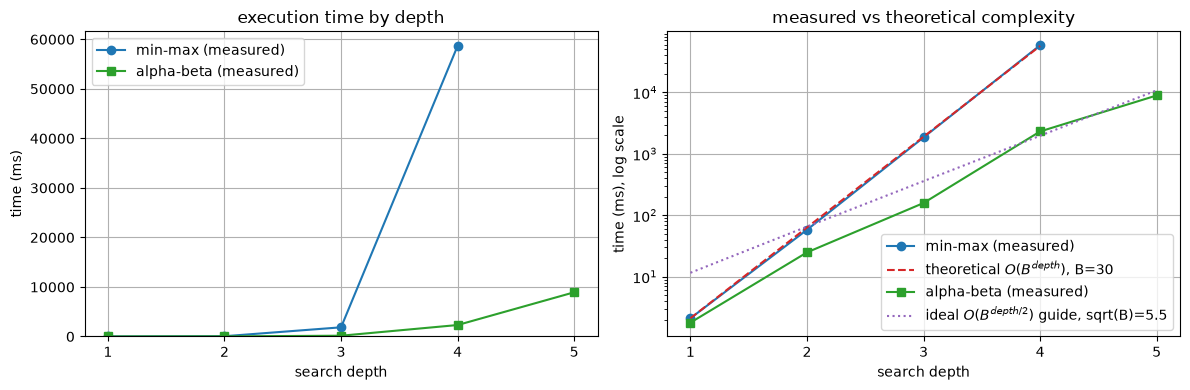

In [2]:
import matplotlib.pyplot as plt

node_cost_ms = naive_times[0] / naive_nodes[0]
predicted_ms = [node_cost_ms * sum(BRANCHING ** k for k in range(d + 1)) for d in DEPTHS]
pruned_guide_ms = [
    pruned_times[0] * sum(BRANCHING ** (k / 2) for k in range(d + 1))
    for d in PRUNED_DEPTHS
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(DEPTHS, naive_times, marker="o", color="tab:blue", label="min-max (measured)")
ax1.plot(PRUNED_DEPTHS, pruned_times, marker="s", color="tab:green", label="alpha-beta (measured)")
ax1.set_xlabel("search depth")
ax1.set_ylabel("time (ms)")
ax1.set_title("execution time by depth")
ax1.set_xticks(PRUNED_DEPTHS)
ax1.set_ylim(bottom=0)
ax1.legend()
ax1.grid(True)

ax2.semilogy(DEPTHS, naive_times, marker="o", color="tab:blue", label="min-max (measured)")
ax2.semilogy(DEPTHS, predicted_ms, linestyle="--", color="tab:red", label=f"theoretical $O(B^{{depth}})$, B={BRANCHING}")
ax2.semilogy(PRUNED_DEPTHS, pruned_times, marker="s", color="tab:green", label="alpha-beta (measured)")
ax2.semilogy(PRUNED_DEPTHS, pruned_guide_ms, linestyle=":", color="tab:purple", label=f"ideal $O(B^{{depth/2}})$ guide, sqrt(B)={BRANCHING ** 0.5:.1f}")
ax2.set_xlabel("search depth")
ax2.set_ylabel("time (ms), log scale")
ax2.set_title("measured vs theoretical complexity")
ax2.set_xticks(PRUNED_DEPTHS)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## Reading the results

1. **The naive growth factor converges to ≈ 30** — each additional depth multiplies the
   tree by `MAX_CANDIDATE_MOVES`: `O(B^depth)` confirmed empirically on the real
   implementation, with the measured curve sitting on the theoretical line derived from
   the per-node cost alone (`T(d) = c · Σ B^k`).
2. **Alpha-beta's growth bends toward ≈ √B ≈ 5.5** — early depths still grow fast (few
   cutoffs while the window is wide), then the factor drops per depth: pruning is not a
   constant speed-up, its saving *compounds* with depth.
3. **Scores are identical at every shared depth** — asserted in the measurement cell.
   Alpha-beta never changes the root decision; only the node count changes (15x at
   depth 3, 41x at depth 4, ~300x at depth 5 against the model).
4. **What one node costs** — roughly six hundredths of a millisecond (≈ 15 000 nodes per
   second), dominated by one full `evaluate` sweep (terminal check + living-set counting)
   plus one candidate generation per visited node — the same per-node work in both variants,
   so the entire difference is the tree size.
5. **Projections** — naive: depth 5 ≈ 30 minutes, depth 6 ≈ 15 hours. Alpha-beta: depth 6
   ≈ 45 seconds — deep lookahead becomes a playable reply time.
6. **Search depth is the engine's strength/cost dial** — every extra ply buys lookahead at a
   multiplicative price; the `depth d` command (default 3) exposes exactly this trade-off,
   and alpha-beta moves the playable range from `depth 2`-`3` to `depth 4`-`5`.